In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.insert(0, str(Path().absolute().parent / 'src'))

from models.graphene import BilayerGrapheneTB, SingleLayerGrapheneTB
from utils.kpath import make_k_path


## AB (Bernal) 堆叠双层 — t=2.78, γ₁=0.39


In [2]:
model_ab = BilayerGrapheneTB(t=2.78, gamma1=0.39)
nb = model_ab.n_bands

kpts = [model_ab.high_symmetry_points()[p] for p in ['Γ', 'M', 'K']]
kvec = make_k_path(kpts, nkdensity=100)
Nk = len(kvec)
E_ab = np.zeros((Nk, nb))
for i in range(Nk):
    Ei, _ = model_ab.solve(kvec[i])
    E_ab[i] = Ei


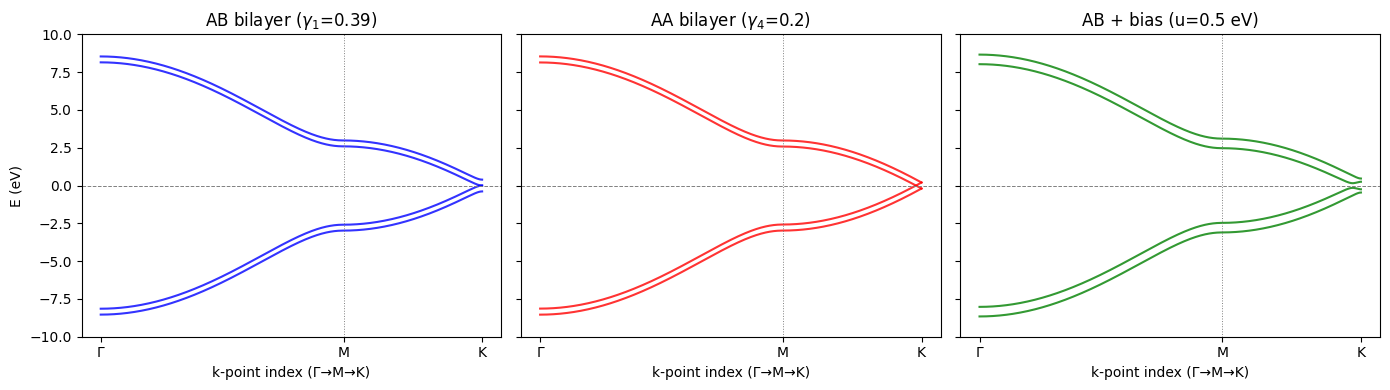

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# AB bilayer
ax = axes[0]
for b in range(nb):
    ax.plot(range(Nk), E_ab[:, b], 'b-', lw=1.5, alpha=0.8)
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.set_title(r'AB bilayer ($\gamma_1$=0.39)')
ax.set_ylabel('E (eV)')
ax.set_xlabel('k-point index (Γ→M→K)')
ax.set_ylim(-10, 10)
kM = len(make_k_path([kpts[0], kpts[1]], nkdensity=100))
ax.axvline(kM, color='gray', ls=':', lw=0.7)
ax.set_xticks([0, kM, Nk-1])
ax.set_xticklabels(['Γ', 'M', 'K'])

# AA bilayer
model_aa = BilayerGrapheneTB(t=2.78, gamma1=0.0, gamma4=0.2)
E_aa = np.zeros((Nk, nb))
for i in range(Nk):
    Ei, _ = model_aa.solve(kvec[i])
    E_aa[i] = Ei

ax = axes[1]
for b in range(nb):
    ax.plot(range(Nk), E_aa[:, b], 'r-', lw=1.5, alpha=0.8)
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.set_title(r'AA bilayer ($\gamma_4$=0.2)')
ax.set_xlabel('k-point index (Γ→M→K)')
ax.set_ylim(-10, 10)
ax.axvline(kM, color='gray', ls=':', lw=0.7)
ax.set_xticks([0, kM, Nk-1])
ax.set_xticklabels(['Γ', 'M', 'K'])

# AB + interlayer bias
model_biased = BilayerGrapheneTB(t=2.78, gamma1=0.39, u=0.5)
E_biased = np.zeros((Nk, nb))
for i in range(Nk):
    Ei, _ = model_biased.solve(kvec[i])
    E_biased[i] = Ei

ax = axes[2]
for b in range(nb):
    ax.plot(range(Nk), E_biased[:, b], 'g-', lw=1.5, alpha=0.8)
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.set_title('AB + bias (u=0.5 eV)')
ax.set_xlabel('k-point index (Γ→M→K)')
ax.set_ylim(-10, 10)
ax.axvline(kM, color='gray', ls=':', lw=0.7)
ax.set_xticks([0, kM, Nk-1])
ax.set_xticklabels(['Γ', 'M', 'K'])

plt.tight_layout()
plt.show()


## K 点附近 zoom-in 对比

AB 双层在 K 点：
- 二聚体分裂带 ±γ₁ = ±0.39 eV（高能，抛物线平坦）
- 两个低能带在 0 接触（抛物线色散 E ∝ k²，有质量费米子）

AA 双层在 K 点：
- 两个 Dirac 锥分开 ±γ₄ = ±0.2 eV
- 每个锥 ±t|f|（线性色散）

AB + 偏压：
- 低位能带在 K 点打开可调带隙


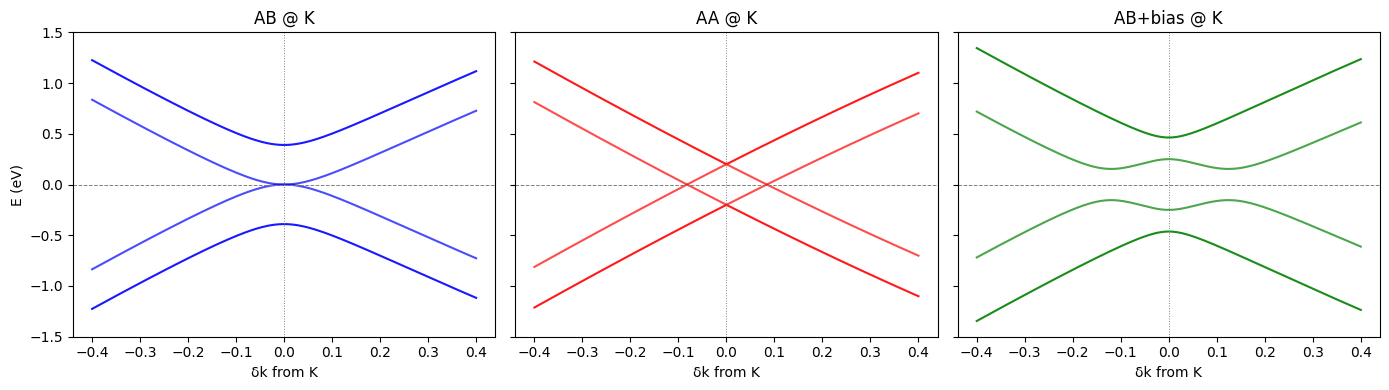

In [4]:
# K 点附近的 k 路径扫描
kK = model_ab.high_symmetry_points()['K']
dk = np.linspace(-0.4, 0.4, 200)
k_scan = np.column_stack([kK[0] + dk, np.full_like(dk, kK[1])])

E_ab_k = np.zeros((200, 4))
E_aa_k = np.zeros((200, 4))
E_biased_k = np.zeros((200, 4))
for i in range(200):
    E_ab_k[i], _ = model_ab.solve(k_scan[i])
    E_aa_k[i], _ = model_aa.solve(k_scan[i])
    E_biased_k[i], _ = model_biased.solve(k_scan[i])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, E, title, color in zip(
    axes,
    [E_ab_k, E_aa_k, E_biased_k],
    ['AB @ K', 'AA @ K', 'AB+bias @ K'],
    ['b', 'r', 'g']
):
    for b in range(4):
        ax.plot(dk, E[:, b], color=color, lw=1.5, alpha=0.7 if b in (1, 2) else 0.9)
    ax.axhline(0, color='gray', ls='--', lw=0.7)
    ax.axvline(0, color='gray', ls=':', lw=0.7)
    ax.set_title(title)
    ax.set_xlabel('δk from K')
    ax.set_ylim(-1.5, 1.5)

axes[0].set_ylabel('E (eV)')
plt.tight_layout()
plt.show()


## 单层 vs 双层对比


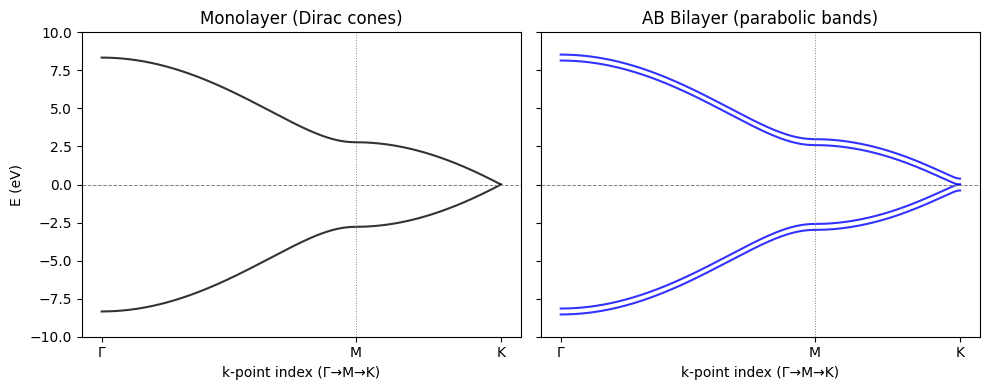

In [5]:
model_sl = SingleLayerGrapheneTB(t=2.78)
kpts_sl = [model_sl.high_symmetry_points()[p] for p in ['Γ', 'M', 'K']]
kvec_sl = make_k_path(kpts_sl, nkdensity=100)
Nk_sl = len(kvec_sl)
E_sl = np.zeros((Nk_sl, 2))
for i in range(Nk_sl):
    Ei, _ = model_sl.solve(kvec_sl[i])
    E_sl[i] = Ei

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for b in range(2):
    ax1.plot(range(Nk_sl), E_sl[:, b], 'k-', lw=1.5, alpha=0.8)
ax1.axhline(0, color='gray', ls='--', lw=0.7)
ax1.set_title('Monolayer (Dirac cones)')
ax1.set_ylabel('E (eV)')
ax1.set_xlabel('k-point index (Γ→M→K)')
ax1.set_ylim(-10, 10)
kM_sl = len(make_k_path([kpts_sl[0], kpts_sl[1]], nkdensity=100))
ax1.axvline(kM_sl, color='gray', ls=':', lw=0.7)
ax1.set_xticks([0, kM_sl, Nk_sl-1])
ax1.set_xticklabels(['Γ', 'M', 'K'])

for b in range(4):
    ax2.plot(range(Nk), E_ab[:, b], 'b-', lw=1.5, alpha=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.7)
ax2.set_title('AB Bilayer (parabolic bands)')
ax2.set_xlabel('k-point index (Γ→M→K)')
ax2.set_ylim(-10, 10)
ax2.axvline(kM, color='gray', ls=':', lw=0.7)
ax2.set_xticks([0, kM, Nk-1])
ax2.set_xticklabels(['Γ', 'M', 'K'])

plt.tight_layout()
plt.show()
